In [125]:
import torch
import gymnasium as gym
from ple import PLE
from ple.games.pixelcopter import Pixelcopter
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from collections import deque
import imageio

import matplotlib.pyplot as plt
import matplotlib.image as mpimg


# Load the trained model
# Note: Adjust path based on your model file structure
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [6]:
# Create the environment
def create_pixelcopter_env():
    game = Pixelcopter()
    env = PLE(game, fps=30)  # Set display=False for headless
    return env
env = create_pixelcopter_env()
env.init()  # Initialize the environment to get the initial state

In [74]:
acts = env.getActionSet()
acts


[119, None]

In [127]:
env.getGameState()

{'player_y': 32.20772962157929,
 'player_vel': 1.0274936401860675,
 'player_dist_to_ceil': 24.20772962157929,
 'player_dist_to_floor': -0.20772962157928987,
 'next_gate_dist_to_player': 28.799999999999983,
 'next_gate_block_top': 28,
 'next_gate_block_bottom': 37}

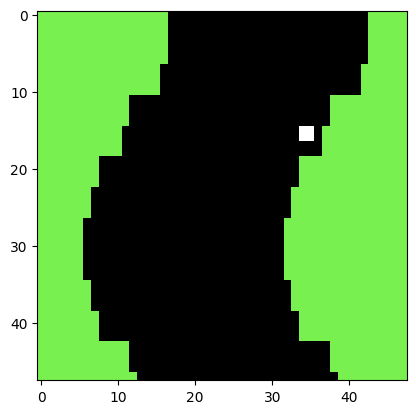

In [46]:
env.reset_game()
img = env.getScreenRGB()
imgplot = plt.imshow(img)
plt.show()

is done: False


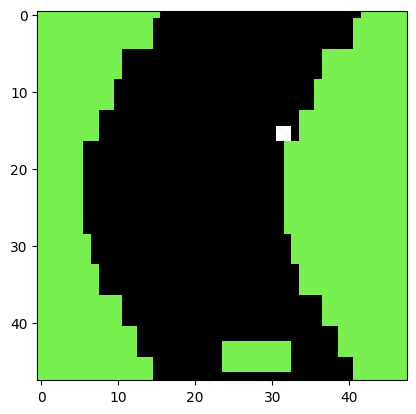

In [124]:
print(f"is done: {env.game_over()}")
if env.game_over():
    print("Game over! Resetting the environment.")
    env.reset_game()
env.act(None)
img = env.getScreenRGB()
imgplot = plt.imshow(img)
plt.show()


In [4]:
def record_video(env, policy, out_directory, fps=30):
    """
    Generate a replay video of the agent
    :param env
    :param Qtable: Qtable of our agent
    :param out_directory
    :param fps: how many frame per seconds (with taxi-v3 and frozenlake-v1 we use 1)
    """
    images = []
    done = False
    state = env.reset_game()
    img = env.render(mode="rgb_array")
    images.append(img)
    while not done:
        # Take the action (index) that have the maximum expected future reward given that state
        action, _ = policy.act(state)
        state, reward, done, info = env.step(
            action
        )  # We directly put next_state = state for recording logic
        img = env.render(mode="rgb_array")
        images.append(img)
    imageio.mimsave(
        out_directory, [np.array(img) for i, img in enumerate(images)], fps=fps
    )
